AlexNet和LeNet的设计理念非常相似，但也存在显著差异。

AlexNet比相对较小的LeNet5要深得多。AlexNet由八层组成：五个卷积层、两个全连接隐藏层和一个全连接输出层。
AlexNet使用ReLU而不是sigmoid作为其激活函数。


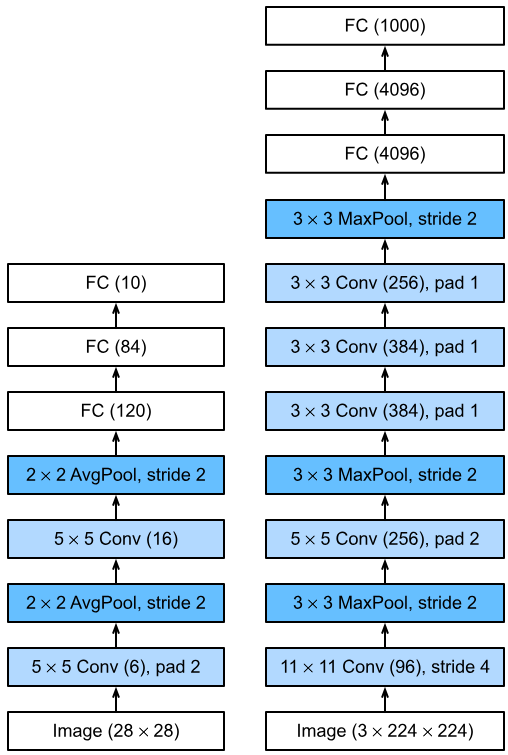

激活函数

使用ReLU激活函数，计算更简单，使用不同的参数初始化方法时，ReLU激活函数使得训练模型更容易，在正区间的梯度总是1。

容量控制和预处理

AlexNet通过暂退法控制全连接层的模型复杂度。为了进一步扩充数据，AlexNet在训练时增加了大量的图像增强数据，增加样本量，减少过拟合。

In [7]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 10)
)

构造一个高度和宽度都为224的单通道数据，来观察每一层输出的形状

In [8]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

读取数据集

直接应用于Fashion-MNIST，但分辨率28*28低于ImageNet，将其增加至224*224

In [10]:
from torch.utils import data
from torchvision import transforms
from torchvision.datasets import FashionMNIST

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]

    if resize:
        trans.insert(0, transforms.Resize(resize))

    trans = transforms.Compose(trans)

    train_dataset = FashionMNIST(
        root="./data", train=True, transform=trans, download=True)

    test_dataset = FashionMNIST(
        root="./data", train=False, transform=trans, download=True)

    train_iter = data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True)

    test_iter = data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False)

    return train_iter, test_iter

In [29]:
batch_size = 128
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)

训练AlexNet

与leNet相比，使用更小的学习速率训练

In [56]:
import torch
from torch import nn

def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()
        if device is None:
            device = next(net.parameters()).device

    metric = [0.0, 0.0]  # 正确数, 总数

    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            pred = net(X).argmax(dim=1)
            metric[0] += (pred == y).sum().item()
            metric[1] += y.numel()

    return metric[0] / metric[1]

def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    print('training on', device)
    net.to(device)

    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        metric = [0.0, 0.0, 0.0]  # 训练损失之和, 训练正确数, 样本总数

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric[0] += l.item() * X.shape[0]
            metric[1] += (y_hat.argmax(dim=1) == y).sum().item()
            metric[2] += y.numel()

        train_loss = metric[0] / metric[2]
        train_acc = metric[1] / metric[2]
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f'epoch {epoch + 1}, '
              f'train loss {train_loss:.4f}, '
              f'train acc {train_acc:.4f}, '
              f'test acc {test_acc:.4f}')

In [14]:
lr, num_epochs = 0.01, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 2.3014, train acc 0.1173, test acc 0.1894
epoch 2, train loss 2.1740, train acc 0.2344, test acc 0.5253
epoch 3, train loss 1.0335, train acc 0.5871, test acc 0.6753
epoch 4, train loss 0.8203, train acc 0.6828, test acc 0.7237
epoch 5, train loss 0.6989, train acc 0.7369, test acc 0.7665
epoch 6, train loss 0.6095, train acc 0.7718, test acc 0.7780
epoch 7, train loss 0.5488, train acc 0.7925, test acc 0.8033
epoch 8, train loss 0.5081, train acc 0.8106, test acc 0.8203
epoch 9, train loss 0.4766, train acc 0.8238, test acc 0.8221
epoch 10, train loss 0.4480, train acc 0.8353, test acc 0.8309


## 练习

1. AlexNet对Fashion-MNIST数据集来说可能太复杂了。
    1. 尝试简化模型以加快训练速度，同时确保准确性不会显著下降。
    1. 设计一个更好的模型，可以直接在$28 \times 28$图像上工作。


方法一：减少卷积通道

In [15]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 5 * 5, 512), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

In [16]:
lr, num_epochs = 0.01, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 2.3013, train acc 0.1221, test acc 0.1841
epoch 2, train loss 1.9110, train acc 0.3063, test acc 0.5305
epoch 3, train loss 0.9168, train acc 0.6389, test acc 0.6869
epoch 4, train loss 0.7695, train acc 0.7092, test acc 0.7130
epoch 5, train loss 0.6686, train acc 0.7490, test acc 0.7721
epoch 6, train loss 0.5958, train acc 0.7748, test acc 0.7841
epoch 7, train loss 0.5460, train acc 0.7947, test acc 0.8013
epoch 8, train loss 0.5082, train acc 0.8093, test acc 0.8044
epoch 9, train loss 0.4818, train acc 0.8202, test acc 0.8263
epoch 10, train loss 0.4580, train acc 0.8294, test acc 0.8338


方法二：减小全连接层规模

In [27]:
net = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),

    nn.Linear(6400, 2048), nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(2048, 512), nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(512, 10)
)

In [30]:
lr, num_epochs = 0.01, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 2.3022, train acc 0.1076, test acc 0.1074
epoch 2, train loss 2.2974, train acc 0.1571, test acc 0.2758
epoch 3, train loss 1.5000, train acc 0.4293, test acc 0.6289
epoch 4, train loss 0.9183, train acc 0.6380, test acc 0.6826
epoch 5, train loss 0.8020, train acc 0.6899, test acc 0.7231
epoch 6, train loss 0.7192, train acc 0.7285, test acc 0.7527
epoch 7, train loss 0.6462, train acc 0.7581, test acc 0.7719
epoch 8, train loss 0.5939, train acc 0.7783, test acc 0.7740
epoch 9, train loss 0.5510, train acc 0.7936, test acc 0.8015
epoch 10, train loss 0.5163, train acc 0.8059, test acc 0.8130


方法三：减少卷积层数

Fashion-MNIST上一般2-3个卷积层就足够

In [21]:
net = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(384 * 5 * 5, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 10)
)

In [22]:
lr, num_epochs = 0.01, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 1.7711, train acc 0.3482, test acc 0.5912
epoch 2, train loss 0.9143, train acc 0.6413, test acc 0.7146
epoch 3, train loss 0.6953, train acc 0.7349, test acc 0.7401
epoch 4, train loss 0.5858, train acc 0.7778, test acc 0.7861
epoch 5, train loss 0.5265, train acc 0.8020, test acc 0.7978
epoch 6, train loss 0.4860, train acc 0.8189, test acc 0.8237
epoch 7, train loss 0.4519, train acc 0.8315, test acc 0.8190
epoch 8, train loss 0.4253, train acc 0.8421, test acc 0.8493
epoch 9, train loss 0.4046, train acc 0.8496, test acc 0.8485
epoch 10, train loss 0.3863, train acc 0.8571, test acc 0.8653


这三种改动虽然明显降低了模型复杂度、减少了参数量并加快了训练速度，但对模型的损失和准确率影响都不大，整体性能仍然比较稳定。

这说明对于 Fashion-MNIST 这样的数据集来说，原始 AlexNet 的结构实际上是偏复杂的。

In [23]:
net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),   # 28 -> 14

    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),   # 14 -> 7

    nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),

    nn.Flatten(),
    nn.Linear(128 * 7 * 7, 256), nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(256, 10)
)

In [25]:
batch_size = 128
train_iter, test_iter = load_data_fashion_mnist(batch_size)

In [26]:
lr, num_epochs = 0.01, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 1.6440, train acc 0.4344, test acc 0.6047
epoch 2, train loss 0.8346, train acc 0.6812, test acc 0.7308
epoch 3, train loss 0.7162, train acc 0.7298, test acc 0.7570
epoch 4, train loss 0.6482, train acc 0.7572, test acc 0.7563
epoch 5, train loss 0.6022, train acc 0.7758, test acc 0.7899
epoch 6, train loss 0.5662, train acc 0.7890, test acc 0.7979
epoch 7, train loss 0.5360, train acc 0.8045, test acc 0.8105
epoch 8, train loss 0.5155, train acc 0.8131, test acc 0.8147
epoch 9, train loss 0.4982, train acc 0.8182, test acc 0.8273
epoch 10, train loss 0.4824, train acc 0.8227, test acc 0.8348


新模型的损失和准确率与原始 AlexNet 相差不大。这个结果说明，对于 Fashion-MNIST 这类低分辨率、类别较少的数据集，并不一定需要像 AlexNet 这样复杂的大模型。原始 AlexNet 虽然结构更深、参数更多，但其优势在该数据集上没有充分体现。

1. 修改批量大小，并观察模型精度和GPU显存变化。

In [33]:
batch_sizes = [32, 64, 128, 256]

for bs in batch_sizes:
    print(f"\n===== batch_size = {bs} =====")

    train_iter, test_iter = load_data_fashion_mnist(bs, resize=224)

    net = nn.Sequential(
        nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Flatten(),
        nn.Linear(6400, 1024), nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(1024, 256), nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 10)
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_ch6(net, train_iter, test_iter, num_epochs=5, lr=0.01, device=device)


===== batch_size = 32 =====
training on cuda
epoch 1, train loss 1.6884, train acc 0.3484, test acc 0.6781
epoch 2, train loss 0.7206, train acc 0.7262, test acc 0.7508
epoch 3, train loss 0.5437, train acc 0.7957, test acc 0.8172
epoch 4, train loss 0.4581, train acc 0.8305, test acc 0.8412
epoch 5, train loss 0.4044, train acc 0.8515, test acc 0.8576

===== batch_size = 64 =====
training on cuda
epoch 1, train loss 2.2905, train acc 0.1558, test acc 0.3566
epoch 2, train loss 1.0331, train acc 0.5876, test acc 0.6807
epoch 3, train loss 0.7439, train acc 0.7186, test acc 0.7484
epoch 4, train loss 0.6115, train acc 0.7718, test acc 0.7903
epoch 5, train loss 0.5345, train acc 0.7980, test acc 0.7922

===== batch_size = 128 =====
training on cuda
epoch 1, train loss 2.3020, train acc 0.1001, test acc 0.1000
epoch 2, train loss 2.2940, train acc 0.1609, test acc 0.3762
epoch 3, train loss 1.2711, train acc 0.5114, test acc 0.6487
epoch 4, train loss 0.8708, train acc 0.6599, test acc 

batch_size 越大，参数更新次数越少，导致学习不充分

1. 分析了AlexNet的计算性能。
    1. 在AlexNet中主要是哪部分占用显存？
    1. 在AlexNet中主要是哪部分需要更多的计算？
    1. 计算结果时显存带宽如何？

AlexNet中显存主要消耗在卷积层产生的大量中间特征图，以及后部大规模全连接层的参数和梯度。其中，卷积层的特征图由于尺寸较大、数量较多，是显存占用的主要来源。

AlexNet中主要的计算开销来自卷积层，因为卷积操作需要在整个特征图上进行大量乘加运算。相比之下，全连接层虽然参数量大，但整体计算量通常低于卷积层。

AlexNet的计算过程中，需要频繁读写输入特征图、卷积核参数和中间激活值，因此对显存带宽有较高要求。在一定情况下，计算性能可能受到显存带宽的限制，使得 GPU 不能充分发挥其计算能力。

显存带宽可以理解为搬运速度。。

1. 将dropout和ReLU应用于LeNet-5，效果有提升吗？再试试预处理会怎么样？

加载数据（没有预处理）

In [34]:
import torch
from torch import nn
from torch.utils import data
from torchvision import transforms
from torchvision.datasets import FashionMNIST

def load_data_fashion_mnist(batch_size, resize=None):
    trans = []
    if resize:
        trans.append(transforms.Resize(resize))
    trans.append(transforms.ToTensor())
    trans = transforms.Compose(trans)

    train_dataset = FashionMNIST(
        root="./data", train=True, transform=trans, download=True)
    test_dataset = FashionMNIST(
        root="./data", train=False, transform=trans, download=True)

    train_iter = data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True)
    test_iter = data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False)

    return train_iter, test_iter

预处理数据

In [43]:
def load_data_fashion_mnist_aug(batch_size, resize=None):
    train_trans = []
    test_trans = []

    if resize:
        train_trans.append(transforms.Resize(resize))
        test_trans.append(transforms.Resize(resize))

    train_trans.extend([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_trans.extend([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_trans = transforms.Compose(train_trans)
    test_trans = transforms.Compose(test_trans)

    train_dataset = FashionMNIST(
        root="./data", train=True, transform=train_trans, download=True)
    test_dataset = FashionMNIST(
        root="./data", train=False, transform=test_trans, download=True)

    train_iter = data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True)
    test_iter = data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False)

    return train_iter, test_iter

模型代码

原始LeNet-5

In [35]:
lenet = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

LeNet-5 + ReLU + Dropout

In [52]:
lenet_relu_dropout = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(120, 84), nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(84, 10)
)

训练

In [36]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()
        if device is None:
            device = next(net.parameters()).device

    metric = [0.0, 0.0]
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            pred = net(X).argmax(dim=1)
            metric[0] += (pred == y).sum().item()
            metric[1] += y.numel()
    return metric[0] / metric[1]


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        metric = [0.0, 0.0, 0.0]  # loss_sum, correct_sum, num_sum

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric[0] += l.item() * X.shape[0]
            metric[1] += (y_hat.argmax(dim=1) == y).sum().item()
            metric[2] += y.numel()

        train_loss = metric[0] / metric[2]
        train_acc = metric[1] / metric[2]
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f'epoch {epoch+1}, '
              f'train loss {train_loss:.4f}, '
              f'train acc {train_acc:.4f}, '
              f'test acc {test_acc:.4f}')

LeNet-5

In [45]:
batch_size = 256
lr, num_epochs = 0.1, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_iter, test_iter = load_data_fashion_mnist(batch_size)

net = lenet
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 0.9397, train acc 0.6192, test acc 0.6244
epoch 2, train loss 0.9170, train acc 0.6276, test acc 0.6306
epoch 3, train loss 0.8977, train acc 0.6339, test acc 0.6406
epoch 4, train loss 0.8804, train acc 0.6416, test acc 0.6446
epoch 5, train loss 0.8638, train acc 0.6491, test acc 0.6510
epoch 6, train loss 0.8475, train acc 0.6581, test acc 0.6623
epoch 7, train loss 0.8304, train acc 0.6690, test acc 0.6720
epoch 8, train loss 0.8131, train acc 0.6825, test acc 0.6745
epoch 9, train loss 0.7957, train acc 0.6921, test acc 0.6992
epoch 10, train loss 0.7786, train acc 0.7030, test acc 0.7017


LeNet-5 + ReLU + Dropout

In [57]:
import torch
from torch import nn

def get_lenet_relu_dropout():
    return nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
        nn.Dropout(p=0.2),

        nn.Linear(120, 84), nn.ReLU(),
        nn.Dropout(p=0.2),

        nn.Linear(84, 10)
    )

In [58]:
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

In [59]:
batch_size = 256
lr, num_epochs = 0.001, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_iter, test_iter = load_data_fashion_mnist(batch_size)

net = get_lenet_relu_dropout()
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 1.0029, train acc 0.6250, test acc 0.7425
epoch 2, train loss 0.6299, train acc 0.7601, test acc 0.7875
epoch 3, train loss 0.5507, train acc 0.7912, test acc 0.8076
epoch 4, train loss 0.5027, train acc 0.8121, test acc 0.8239
epoch 5, train loss 0.4715, train acc 0.8266, test acc 0.8373
epoch 6, train loss 0.4497, train acc 0.8348, test acc 0.8439
epoch 7, train loss 0.4307, train acc 0.8436, test acc 0.8515
epoch 8, train loss 0.4139, train acc 0.8484, test acc 0.8558
epoch 9, train loss 0.3976, train acc 0.8543, test acc 0.8569
epoch 10, train loss 0.3837, train acc 0.8595, test acc 0.8590


LeNet-5 + ReLU + Dropout + 预处理

In [60]:
batch_size = 256
lr, num_epochs = 0.011, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_iter, test_iter = load_data_fashion_mnist_aug(batch_size)

net = get_lenet_relu_dropout()
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 0.7108, train acc 0.7263, test acc 0.8164
epoch 2, train loss 0.4623, train acc 0.8340, test acc 0.8431
epoch 3, train loss 0.3993, train acc 0.8566, test acc 0.8671
epoch 4, train loss 0.3724, train acc 0.8648, test acc 0.8723
epoch 5, train loss 0.3578, train acc 0.8712, test acc 0.8764
epoch 6, train loss 0.3463, train acc 0.8770, test acc 0.8784
epoch 7, train loss 0.3374, train acc 0.8793, test acc 0.8822
epoch 8, train loss 0.3262, train acc 0.8833, test acc 0.8804
epoch 9, train loss 0.3221, train acc 0.8833, test acc 0.8889
epoch 10, train loss 0.3313, train acc 0.8810, test acc 0.8838


AlexNet 模型结构复杂，参数量大，主要针对高分辨率图像任务设计。而 Fashion-MNIST 数据集规模较小、任务相对简单，使用 AlexNet 会造成计算资源浪费，并且模型优势难以体现。相比之下，LeNet-5 及其改进版本更加轻量，能够更高效地提取特征，因此在该任务上表现更优。

将激活函数由 Sigmoid 替换为 ReLU 后，模型训练更加稳定，收敛速度明显加快。同时，引入 Dropout 有效抑制了过拟合，使训练集和测试集性能更加接近，从而显著提升了模型的泛化能力。

在加入数据预处理后，模型性能进一步提升。这是因为标准化使输入数据分布更加稳定，有利于模型训练；同时，数据增强提高了样本多样性，使模型具备更强的泛化能力。